<a href="https://colab.research.google.com/github/narayn02/Codealpha_tasks/blob/main/Car_Price_Prediction_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")

In [3]:
from google.colab import files

uploaded = files.upload()


Saving car data.csv to car data.csv


In [4]:
df = pd.read_csv("car data.csv")

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [5]:
print("Shape of dataset:", df.shape)

df.head()
df.info()
df.describe()

Shape of dataset: (301, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Driven_kms     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Selling_type   301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


,Year,Selling_Price,Present_Price,Driven_kms,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,0.043189
std,2.891554,5.082812,8.642584,38886.883882,0.247915
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


**CHECK MISSING VALUES**

In [6]:
missing_values = df.isnull().sum()

print("Missing values:")
print(missing_values)

print("Total missing values:", df.isnull().sum().sum())

Missing values:
Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Driven_kms       0
Fuel_Type        0
Selling_type     0
Transmission     0
Owner            0
dtype: int64
Total missing values: 0


**CHECK DUPLICATE ROWS**

In [7]:
print("Number of duplicate rows:", df.duplicated().sum())

df = df.drop_duplicates().reset_index(drop=True)

print("Dataset shape after removing duplicates:", df.shape)

Number of duplicate rows: 2
Dataset shape after removing duplicates: (299, 9)


**CHECK CATEGORICAL VALUES**

In [8]:
categorical_columns = [
    "Fuel_Type",
    "Selling_type",
    "Transmission"
]

for column in categorical_columns:
    print(f"\n{column}:")
    print(df[column].value_counts())


Fuel_Type:
Fuel_Type
Petrol    239
Diesel     58
CNG         2
Name: count, dtype: int64

Selling_type:
Selling_type
Dealer        193
Individual    106
Name: count, dtype: int64

Transmission:
Transmission
Manual       260
Automatic     39
Name: count, dtype: int64


In [11]:
current_year = 2026
df["Car_Age"] = current_year - df["Year"]
df[["Year", "Car_Age"]].head()

,Year,Car_Age
0,2014,12
1,2013,13
2,2017,9
3,2011,15
4,2014,12


***`EXPLORATORY DATA ANALYSIS`***

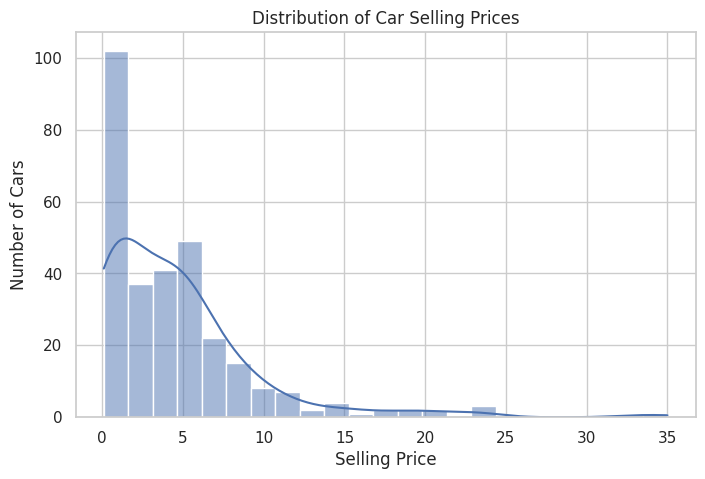

In [12]:
plt.figure(figsize=(8, 5))

sns.histplot(df["Selling_Price"], kde=True)

plt.title("Distribution of Car Selling Prices")
plt.xlabel("Selling Price")
plt.ylabel("Number of Cars")

plt.show()

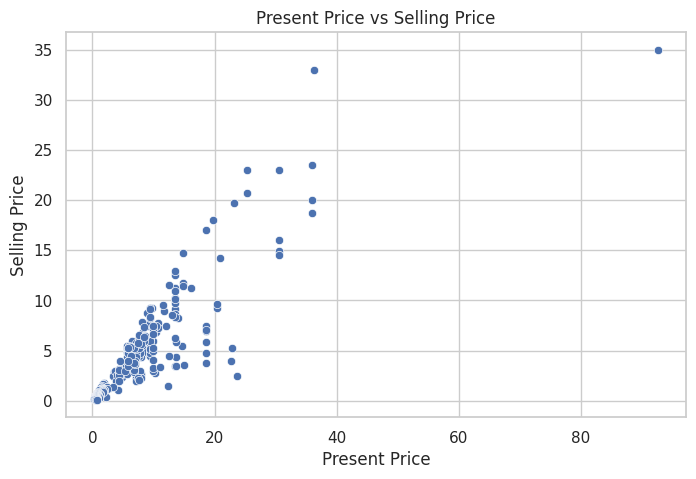

In [13]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="Present_Price",
    y="Selling_Price"
)

plt.title("Present Price vs Selling Price")
plt.xlabel("Present Price")
plt.ylabel("Selling Price")

plt.show()

**CAR AGE VS SELLING PRICE**

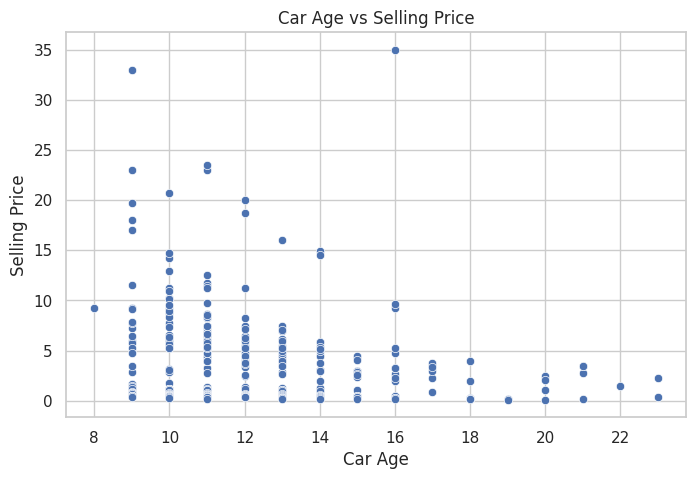

In [14]:
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=df,
    x="Car_Age",
    y="Selling_Price"
)
plt.title("Car Age vs Selling Price")
plt.xlabel("Car Age")
plt.ylabel("Selling Price")
plt.show()

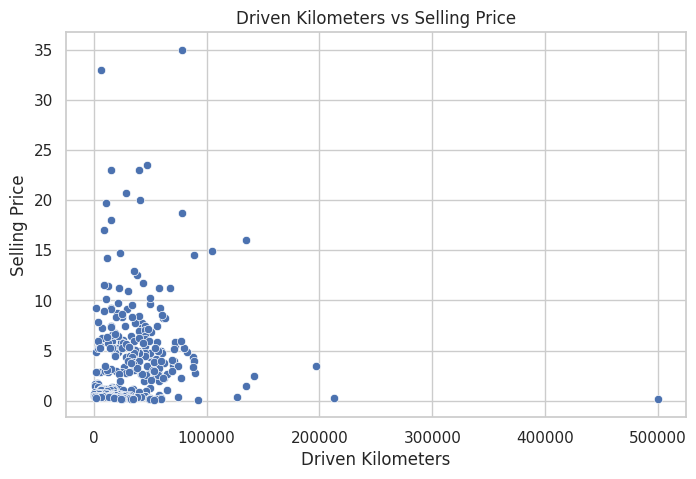

In [15]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="Driven_kms",
    y="Selling_Price"
)
plt.title("Driven Kilometers vs Selling Price")
plt.xlabel("Driven Kilometers")
plt.ylabel("Selling Price")
plt.show()

**FUEL TYPE ANALYSIS**

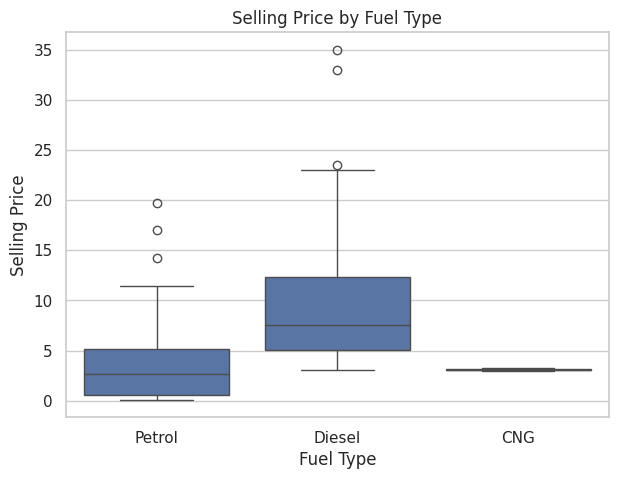

In [16]:
plt.figure(figsize=(7, 5))
sns.boxplot(
    data=df,
    x="Fuel_Type",
    y="Selling_Price"
)
plt.title("Selling Price by Fuel Type")
plt.xlabel("Fuel Type")
plt.ylabel("Selling Price")
plt.show()

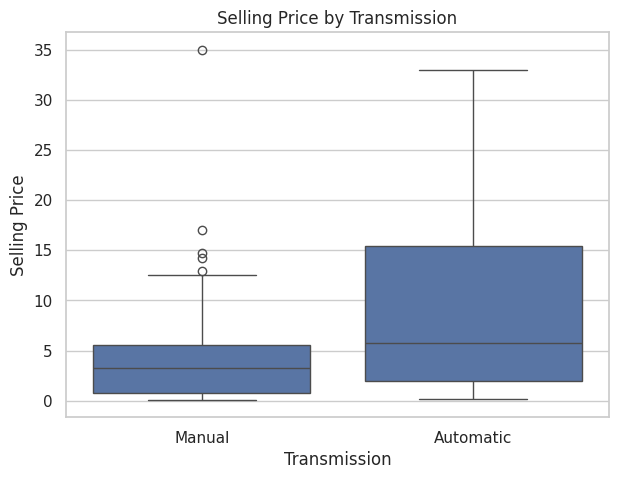

In [17]:
plt.figure(figsize=(7, 5))
sns.boxplot(
    data=df,
    x="Transmission",
    y="Selling_Price"
)
plt.title("Selling Price by Transmission")
plt.xlabel("Transmission")
plt.ylabel("Selling Price")
plt.show()

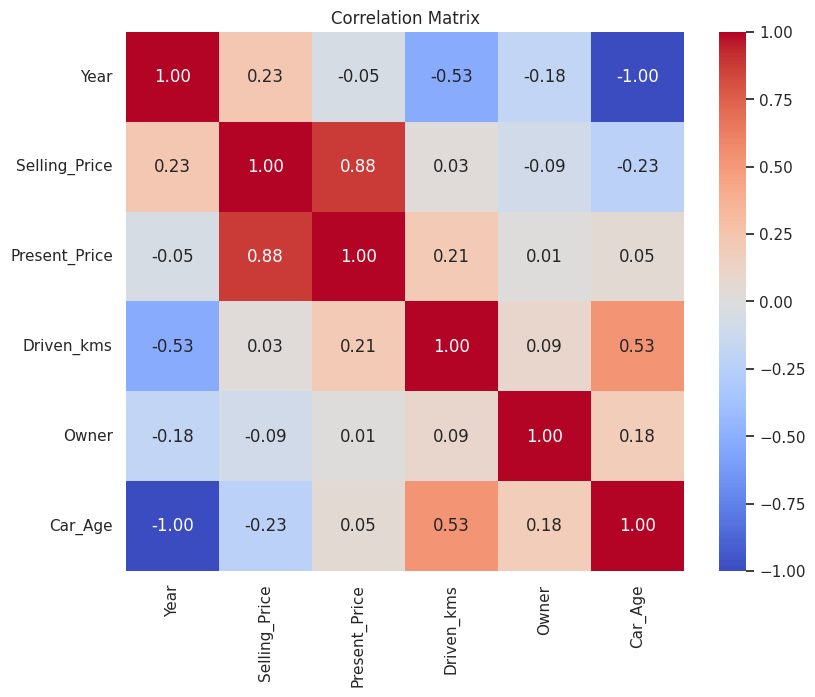

In [18]:
numeric_df = df.select_dtypes(include=np.number)

correlation = numeric_df.corr()

plt.figure(figsize=(9, 7))
sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)
plt.title("Correlation Matrix")
plt.show()

***`MACHINE LEARNING`***

In [19]:
X = df.drop(
    columns=["Selling_Price", "Car_Name", "Year"]
)
y = df["Selling_Price"]
print("Features:")
print(X.columns.tolist())

print("\nTarget:")
print("Selling_Price")

Features:
['Present_Price', 'Driven_kms', 'Fuel_Type', 'Selling_type', 'Transmission', 'Owner', 'Car_Age']

Target:
Selling_Price


Train-Test Split

In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)
print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 239
Testing samples: 60


**Preprocessing**
*convert categorical variable into numerical form

In [21]:
categorical_features = [
    "Fuel_Type",
    "Selling_type",
    "Transmission"
]

numerical_features = [
    "Present_Price",
    "Driven_kms",
    "Owner",
    "Car_Age"
]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        ),
        (
            "numerical",
            "passthrough",
            numerical_features
        )
    ]
)

***`MODEL 1 --- Linear Regression`***

In [22]:
linear_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LinearRegression())
    ]
)
linear_model.fit(X_train, y_train)

linear_predictions = linear_model.predict(X_test)

In [23]:
linear_mae = mean_absolute_error(
    y_test,
    linear_predictions
)

linear_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        linear_predictions
    )
)

linear_r2 = r2_score(
    y_test,
    linear_predictions
)

print("Linear Regression")
print("MAE :", linear_mae)
print("RMSE:", linear_rmse)
print("R²  :", linear_r2)

Linear Regression
MAE : 1.4725457508178263
RMSE: 2.524504923001791
R²  : 0.7527233824220652


***`MODEL 2 --- Decision Tree`***

In [25]:
tree_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", DecisionTreeRegressor(
            random_state=42,
            max_depth=8
        ))
    ]
)
tree_model.fit(X_train, y_train)

tree_predictions = tree_model.predict(X_test)

In [27]:
tree_mae = mean_absolute_error(
    y_test,
    tree_predictions
)
tree_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        tree_predictions
    )
)
tree_r2 = r2_score(
    y_test,
    tree_predictions
)
print("Decision Tree")
print("MAE :", tree_mae)
print("RMSE:", tree_rmse)
print("R²  :", tree_r2)

Decision Tree
MAE : 1.0972652777777776
RMSE: 2.1037579691509674
R²  : 0.8282794954474101


***`MODEL 3 --- Random Forest`***

In [28]:
rf_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestRegressor(
            n_estimators=300,
            random_state=42
        ))
    ]
)
rf_model.fit(X_train, y_train)

rf_predictions = rf_model.predict(X_test)

In [29]:
rf_mae = mean_absolute_error(
    y_test,
    rf_predictions
)
rf_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        rf_predictions
    )
)
rf_r2 = r2_score(
    y_test,
    rf_predictions
)
print("Random Forest")
print("MAE :", rf_mae)
print("RMSE:", rf_rmse)
print("R²  :", rf_r2)

Random Forest
MAE : 1.5063261111111095
RMSE: 3.61184675622637
R²  : 0.4938383477426107


***`MODEL 4 --- Gradient Boosting`***

In [30]:
gb_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", GradientBoostingRegressor(
            n_estimators=200,
            learning_rate=0.05,
            max_depth=3,
            random_state=42
        ))
    ]
)
gb_model.fit(X_train, y_train)

gb_predictions = gb_model.predict(X_test)

In [31]:
gb_mae = mean_absolute_error(
    y_test,
    gb_predictions
)
gb_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        gb_predictions
    )
)
gb_r2 = r2_score(
    y_test,
    gb_predictions
)
print("Gradient Boosting")
print("MAE :", gb_mae)
print("RMSE:", gb_rmse)
print("R²  :", gb_r2)

Gradient Boosting
MAE : 1.168937231776748
RMSE: 2.6668805880068187
R²  : 0.724045330025965


COmpare all Models

In [33]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree",
        "Random Forest",
        "Gradient Boosting"
    ],
    "MAE": [
        linear_mae,
        tree_mae,
        rf_mae,
        gb_mae
    ],
    "RMSE": [
        linear_rmse,
        tree_rmse,
        rf_rmse,
        gb_rmse
    ],
    "R2 Score": [
        linear_r2,
        tree_r2,
        rf_r2,
        gb_r2
    ]
})

results.sort_values(
    by="R2 Score",
    ascending=False
).reset_index(drop=True)

,Model,MAE,RMSE,R2 Score
0,Decision Tree,1.097265,2.103758,0.828279
1,Linear Regression,1.472546,2.524505,0.752723
2,Gradient Boosting,1.168937,2.666881,0.724045
3,Random Forest,1.506326,3.611847,0.493838


Visualization Of model Comparision

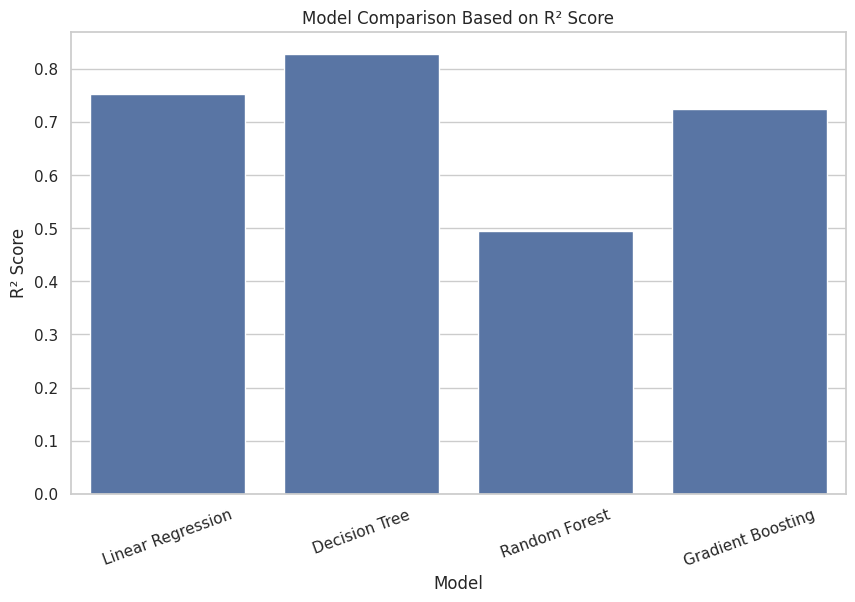

In [34]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=results,
    x="Model",
    y="R2 Score"
)
plt.title("Model Comparison Based on R² Score")
plt.xlabel("Model")
plt.ylabel("R² Score")

plt.xticks(rotation=20)

plt.show()

ACTUAL VS PREDICTED

In [37]:
best_model_name = results.loc[
    results["R2 Score"].idxmax(),
    "Model"
]
print("Best model based on R²:", best_model_name)

Best model based on R²: Decision Tree


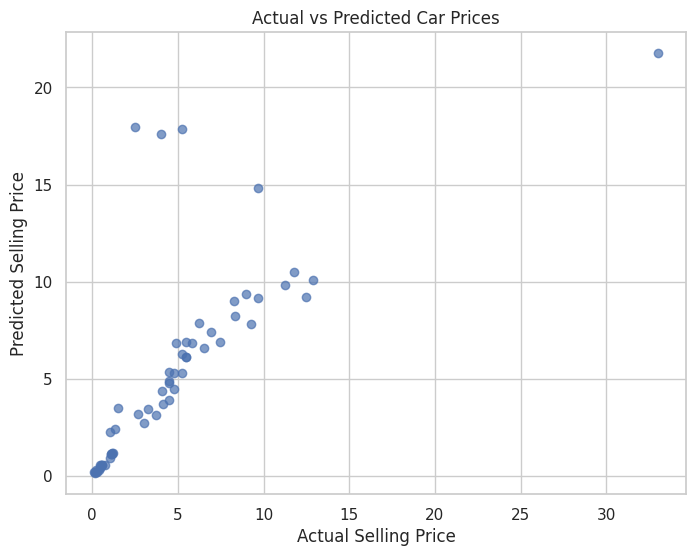

In [38]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    rf_predictions,
    alpha=0.7
)
plt.xlabel("Actual Selling Price")
plt.ylabel("Predicted Selling Price")

plt.title("Actual vs Predicted Car Prices")
plt.show()

One realistic prediction fron the test datasets

In [39]:
sample_car = X_test.iloc[[0]]

actual_price = y_test.iloc[0]

predicted_price = rf_model.predict(sample_car)[0]

print("Actual Selling Price:", actual_price)
print("Predicted Selling Price:", predicted_price)

Actual Selling Price: 8.99
Predicted Selling Price: 9.370233333333335


Feature Importance

In [40]:
rf_preprocessor = rf_model.named_steps["preprocessor"]
rf_regressor = rf_model.named_steps["model"]

feature_names = rf_preprocessor.get_feature_names_out()

importance = rf_regressor.feature_importances_

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
}).sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(15)

,Feature,Importance
7,numerical__Present_Price,0.901563
10,numerical__Car_Age,0.072562
8,numerical__Driven_kms,0.013421
6,categorical__Transmission_Manual,0.003912
5,categorical__Transmission_Automatic,0.003360
4,categorical__Selling_type_Individual,0.001965
3,categorical__Selling_type_Dealer,0.001312
2,categorical__Fuel_Type_Petrol,0.000954
1,categorical__Fuel_Type_Diesel,0.000939
9,numerical__Owner,0.000009


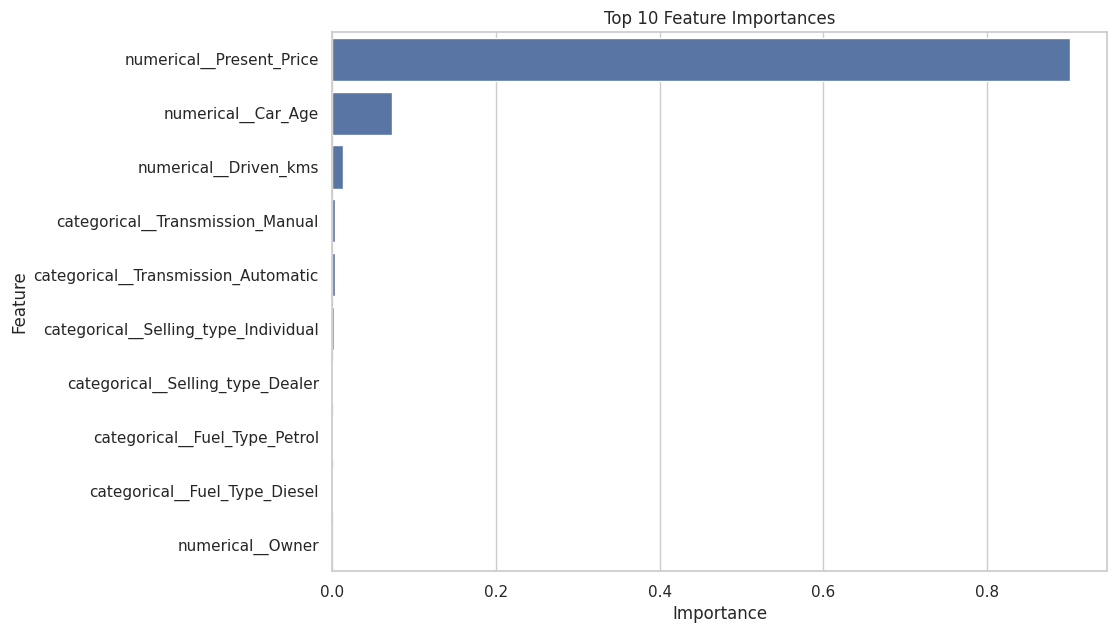

In [41]:
plt.figure(figsize=(10, 7))

sns.barplot(
    data=feature_importance.head(10),
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Feature Importances")

plt.show()